# Musical Form Trigram Analysis

Analysis of musical section sequences (intro, verse, chorus, bridge, solo, outro, etc.) across collections.

1. Extract section sequences from `_musical_form.lab` files
2. Form trigrams of consecutive sections
3. Build per-collection JSON datasets with genre metadata
4. Visualize the most common section trigrams
5. Byte-pair encoding (BPE) of full section sequences to discover higher-order patterns

## 1. Load Musical Form Sequences

In [1]:
import os, json, glob
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

COLLECTIONS = ['lastfm', 'suno', 'udio']
DATASET_ROOT = '/workspace/dataset'
NGRAM_OUT    = '/workspace/ngram_datasets/trigrams'

def collapse_repeats(sections):
    """Collapse consecutive identical sections: [verse, verse, chorus] -> [verse, chorus]"""
    if not sections:
        return []
    result = [sections[0]]
    for s in sections[1:]:
        if s != result[-1]:
            result.append(s)
    return result

def load_musical_form(lab_path):
    """Parse a _musical_form.lab file -> list of section labels (strings)."""
    sections = []
    with open(lab_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 3:
                sections.append(parts[2])
    return sections

def load_style(style_path):
    """Load genre metadata from _style.json."""
    with open(style_path) as f:
        data = json.load(f)
    dortmund = {}
    if 'genre_dortmund' in data:
        dortmund = {k: float(v) for k, v in data['genre_dortmund'].items()}
    human_styles = []
    if 'original' in data:
        orig = data['original']
        if isinstance(orig, list):
            human_styles = orig
        elif isinstance(orig, str):
            human_styles = [s.strip() for s in orig.split(',')]
    return dortmund, human_styles

# Load all sequences per collection
collection_data = {}  # {collection: [(song_id, sections, dortmund, human_styles), ...]}

for collection in COLLECTIONS:
    coll_path = os.path.join(DATASET_ROOT, collection)
    songs = []
    for song_id in sorted(os.listdir(coll_path)):
        song_dir = os.path.join(coll_path, song_id)
        if not os.path.isdir(song_dir):
            continue
        form_file = os.path.join(song_dir, f'{song_id}_musical_form.lab')
        style_file = os.path.join(song_dir, f'{song_id}_style.json')
        if not os.path.exists(form_file):
            continue
        sections = load_musical_form(form_file)
        if len(sections) < 3:
            continue
        dortmund, human_styles = {}, []
        if os.path.exists(style_file):
            dortmund, human_styles = load_style(style_file)
        songs.append((song_id, sections, dortmund, human_styles))
    collection_data[collection] = songs
    print(f'{collection}: {len(songs)} songs with musical form')

lastfm: 19910 songs with musical form
suno: 19898 songs with musical form
udio: 19355 songs with musical form


## 2. Section Vocabulary Overview

In [2]:
# Section label distribution per collection
for collection in COLLECTIONS:
    section_counter = Counter()
    for _, sections, _, _ in collection_data[collection]:
        section_counter.update(sections)
    print(f'\n{collection.upper()} section counts:')
    for label, count in section_counter.most_common():
        print(f'  {label:12s} {count:>8,}')


LASTFM section counts:
  chorus         76,266
  verse          62,420
  intro          39,139
  solo           30,073
  end            24,927
  inst           20,094
  start          17,214
  outro          17,010
  bridge          5,112
  break           2,256

SUNO section counts:
  chorus         59,716
  verse          54,199
  outro          16,686
  intro          15,689
  inst           14,883
  start          14,801
  solo           14,721
  end            10,016
  bridge          2,194
  break           1,161

UDIO section counts:
  verse          50,929
  chorus         50,647
  intro          18,019
  solo           15,352
  inst           11,920
  end             9,109
  outro           7,020
  start           6,014
  bridge          1,998
  break             956


## 3. Form Section Trigrams & Build Dataset

In [3]:
def extract_section_trigrams(sections):
    """Extract all consecutive trigrams from a section sequence."""
    trigrams = []
    for i in range(len(sections) - 2):
        trigrams.append(tuple(sections[i:i+3]))
    return trigrams

def build_trigram_dataset(collection_data, collection):
    """
    Build a trigram dataset for one collection.
    Returns list of dicts: {ngram, count, human_styles, dortmund_genres, song_ids, num_songs}
    """
    trigram_counter = Counter()
    trigram_songs = defaultdict(set)
    trigram_dortmund = defaultdict(Counter)      # trigram -> {genre: weight_sum}
    trigram_human = defaultdict(Counter)          # trigram -> {style: count}
    
    for song_id, sections, dortmund, human_styles in collection_data[collection]:
        # Collapse consecutive repeats so every trigram has 3 distinct transitions
        collapsed = collapse_repeats([s for s in sections if s not in ('start', 'end')])
        trigrams = extract_section_trigrams(collapsed)
        local_trigrams = set(trigrams)  # unique per song for genre weighting
        
        for tri in trigrams:
            trigram_counter[tri] += 1
            trigram_songs[tri].add(song_id)
        
        # Weight genres once per unique trigram per song
        for tri in local_trigrams:
            for genre, weight in dortmund.items():
                trigram_dortmund[tri][genre] += weight
            for style in human_styles:
                trigram_human[tri][style.lower()] += 1
    
    # Build output list sorted by count
    dataset = []
    for tri, count in trigram_counter.most_common():
        entry = {
            'ngram': list(tri),
            'count': count,
            'human_styles': sorted(trigram_human[tri].items(), key=lambda x: -x[1]),
            'dortmund_genres': sorted(trigram_dortmund[tri].items(), key=lambda x: -x[1]),
            'song_ids': sorted(list(trigram_songs[tri]))[:50],  # cap to save space
            'num_songs': len(trigram_songs[tri]),
        }
        dataset.append(entry)
    return dataset

# Build and save datasets
os.makedirs(NGRAM_OUT, exist_ok=True)

trigram_datasets = {}
for collection in COLLECTIONS:
    ds = build_trigram_dataset(collection_data, collection)
    trigram_datasets[collection] = ds
    
    out_path = os.path.join(NGRAM_OUT, f'3gram_musical_form_{collection}.json')
    with open(out_path, 'w') as f:
        json.dump(ds, f, indent=1)
    print(f'{collection}: {len(ds)} unique trigrams, saved to {out_path}')

lastfm: 319 unique trigrams, saved to /workspace/ngram_datasets/trigrams/3gram_musical_form_lastfm.json
suno: 298 unique trigrams, saved to /workspace/ngram_datasets/trigrams/3gram_musical_form_suno.json
udio: 286 unique trigrams, saved to /workspace/ngram_datasets/trigrams/3gram_musical_form_udio.json


## 4. Top Section Trigrams per Collection

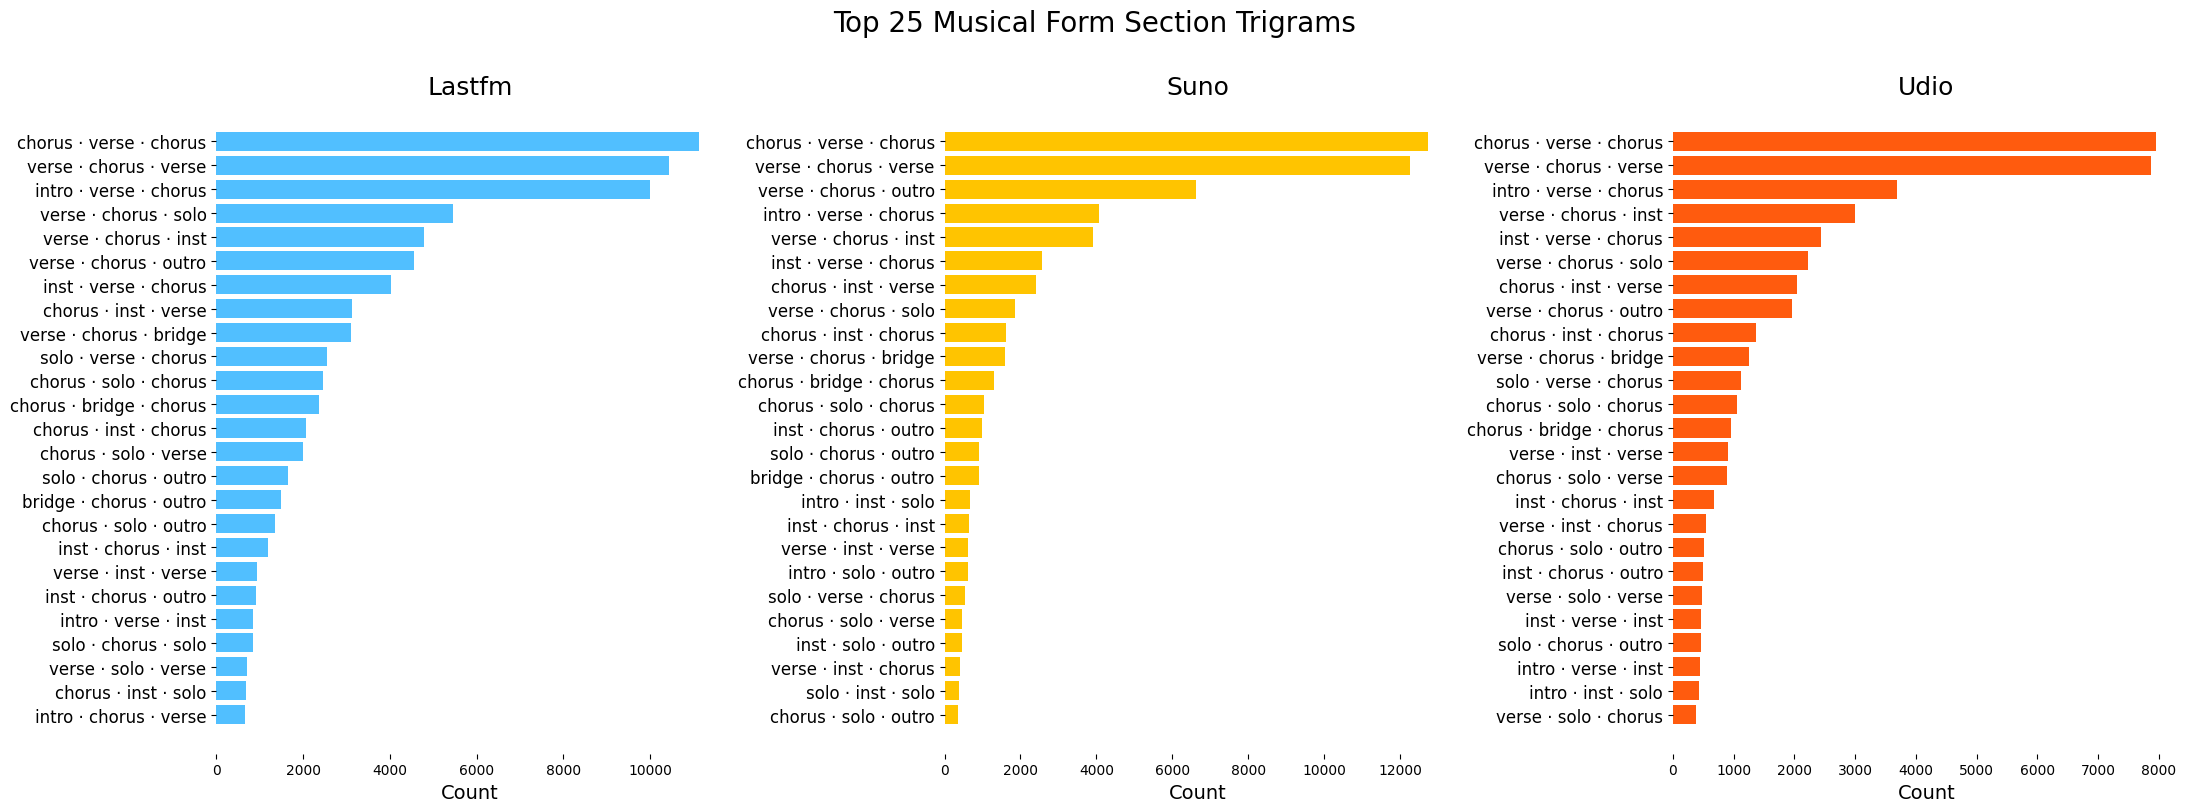

In [4]:
N = 25

fig, axes = plt.subplots(1, 3, figsize=(22, 8), sharey=False)
colors_coll = {'lastfm': '#51BFFF', 'suno': '#FFC400', 'udio': '#FF5B0E'}

for ax, collection in zip(axes, COLLECTIONS):
    ds = trigram_datasets[collection]
    top = ds[:N]
    labels = [' · '.join(e['ngram']) for e in top][::-1]
    counts = [e['count'] for e in top][::-1]
    
    ax.barh(labels, counts, color=colors_coll[collection])
    ax.set_title(f'{collection.capitalize()}', fontsize=18)
    ax.set_xlabel('Count', fontsize=14)
    ax.tick_params(axis='y', labelsize=12)
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.suptitle(f'Top {N} Musical Form Section Trigrams', fontsize=20, y=1.01)
plt.tight_layout()
plt.savefig('../Figures/musical_form_top_trigrams.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Comparative Prevalence (Stacked Bar per Collection)

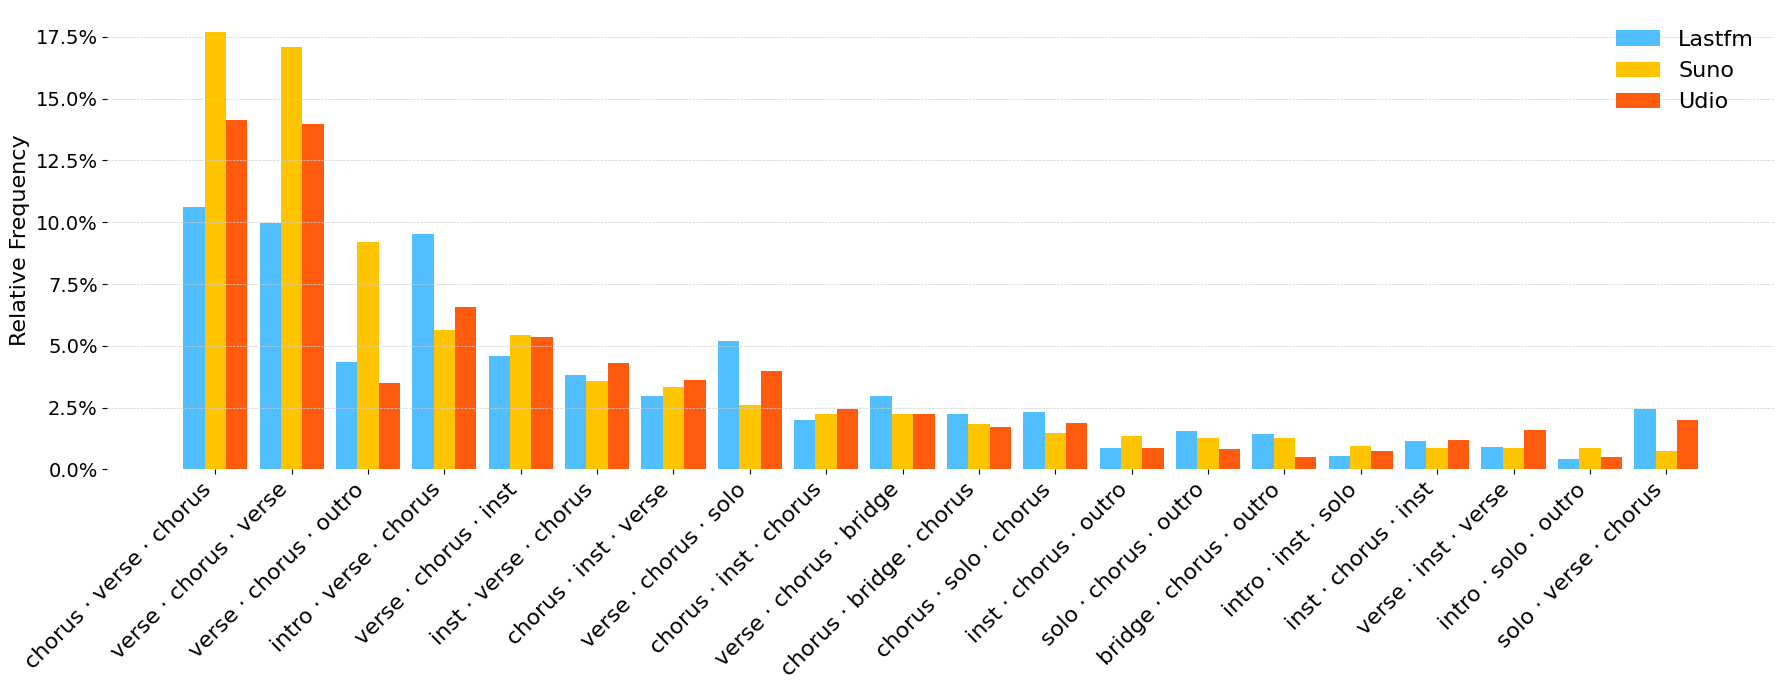

chorus·verse·chorus             Suno/Lastfm: 1.67  Suno/Udio: 1.25
verse·chorus·verse              Suno/Lastfm: 1.71  Suno/Udio: 1.22
verse·chorus·outro              Suno/Lastfm: 2.12  Suno/Udio: 2.65
intro·verse·chorus              Suno/Lastfm: 0.59  Suno/Udio: 0.86
verse·chorus·inst               Suno/Lastfm: 1.19  Suno/Udio: 1.02
inst·verse·chorus               Suno/Lastfm: 0.93  Suno/Udio: 0.83
chorus·inst·verse               Suno/Lastfm: 1.12  Suno/Udio: 0.92
verse·chorus·solo               Suno/Lastfm: 0.50  Suno/Udio: 0.65
chorus·inst·chorus              Suno/Lastfm: 1.13  Suno/Udio: 0.92
verse·chorus·bridge             Suno/Lastfm: 0.75  Suno/Udio: 1.00
chorus·bridge·chorus            Suno/Lastfm: 0.81  Suno/Udio: 1.07
chorus·solo·chorus              Suno/Lastfm: 0.62  Suno/Udio: 0.77
inst·chorus·outro               Suno/Lastfm: 1.57  Suno/Udio: 1.56
solo·chorus·outro               Suno/Lastfm: 0.81  Suno/Udio: 1.53
bridge·chorus·outro             Suno/Lastfm: 0.88  Suno/Udio: 

In [5]:
# Get the union of top trigrams across all collections
from collections import OrderedDict

# Use Suno's ranking as the base ordering
N_compare = 20
suno_top = [tuple(e['ngram']) for e in trigram_datasets['suno'][:N_compare]]

# Compute total trigrams per collection for relative frequency
total_trigrams = {}
trigram_lookup = {}  # {(collection, trigram_tuple): count}
for collection in COLLECTIONS:
    total = sum(e['count'] for e in trigram_datasets[collection])
    total_trigrams[collection] = total
    for e in trigram_datasets[collection]:
        trigram_lookup[(collection, tuple(e['ngram']))] = e['count']

# Plot grouped bars
trigram_names = [' · '.join(tri) for tri in suno_top]
proportions = {}
for col in COLLECTIONS:
    proportions[col] = [trigram_lookup.get((col, tri), 0) / total_trigrams[col] for tri in suno_top]

bar_width = 0.28
x = np.arange(len(trigram_names))
colors_coll = {'lastfm': '#51BFFF', 'suno': '#FFC400', 'udio': '#FF5B0E'}

fig, ax = plt.subplots(figsize=(18, 7))
for i, col in enumerate(COLLECTIONS):
    ax.bar(x + i * bar_width, proportions[col], width=bar_width,
           label=col.capitalize(), color=colors_coll[col])

text_size = 16
ax.set_xticks(x + bar_width)
ax.set_xticklabels(trigram_names, rotation=45, ha='right', fontsize=text_size)
ax.set_ylabel('Relative Frequency', fontsize=text_size)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))
ax.tick_params(axis='y', labelsize=text_size - 2)
ax.legend(fontsize=text_size, frameon=False)
ax.grid(axis='y', linestyle='--', linewidth=0.5, color='#cdcdcd')
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig('../Figures/musical_form_trigram_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Print ratios
for i, tri in enumerate(suno_top):
    s = proportions['suno'][i]
    l = proportions['lastfm'][i]
    u = proportions['udio'][i]
    r_l = s / l if l > 0 else float('inf')
    r_u = s / u if u > 0 else float('inf')
    print(f"{'·'.join(tri):30s}  Suno/Lastfm: {r_l:.2f}  Suno/Udio: {r_u:.2f}")

## 6. Statistical Tests (Fisher's Exact) — Suno vs Others

In [6]:
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# Build counts per collection
coll_trigram_counts = {}
coll_totals = {}
for collection in COLLECTIONS:
    ctr = Counter()
    for e in trigram_datasets[collection]:
        ctr[tuple(e['ngram'])] = e['count']
    coll_trigram_counts[collection] = ctr
    coll_totals[collection] = sum(ctr.values())

# Suno-enriched trigrams vs LastFM
vocab = set()
for col in COLLECTIONS:
    vocab |= set(coll_trigram_counts[col].keys())

rows = []
for tri in vocab:
    cs = coll_trigram_counts['suno'].get(tri, 0)
    cl = coll_trigram_counts['lastfm'].get(tri, 0)
    cu = coll_trigram_counts['udio'].get(tri, 0)
    ts, tl, tu = coll_totals['suno'], coll_totals['lastfm'], coll_totals['udio']
    
    rr_sl = (cs / ts) / (cl / tl) if cl > 0 else np.inf
    _, pval_sl = fisher_exact([[cs, ts - cs], [cl, tl - cl]])
    _, pval_su = fisher_exact([[cs, ts - cs], [cu, tu - cu]]) if tu > 0 else (0, 1.0)
    
    rows.append({
        'trigram': tri,
        'c_suno': cs, 'c_lastfm': cl, 'c_udio': cu,
        'pct_suno': cs / ts * 100, 'pct_lastfm': cl / tl * 100,
        'pct_udio': cu / tu * 100 if tu > 0 else 0,
        'risk_ratio_sl': rr_sl,
        'p_suno_lastfm': pval_sl,
        'p_suno_udio': pval_su,
    })

df_stats = pd.DataFrame(rows)
df_stats['padj_sl'] = multipletests(df_stats['p_suno_lastfm'], method='fdr_bh')[1]
df_stats['padj_su'] = multipletests(df_stats['p_suno_udio'], method='fdr_bh')[1]

# Suno-enriched vs LastFM
MIN_COUNT = 50
enriched = df_stats[
    (df_stats['c_suno'] >= MIN_COUNT) &
    (df_stats['c_lastfm'] >= 10) &
    (df_stats['risk_ratio_sl'] >= 1.5) &
    (df_stats['padj_sl'] < 0.05)
].sort_values('risk_ratio_sl', ascending=False)

print(f'Suno-enriched section trigrams (vs LastFM): {len(enriched)}')
display(enriched[['trigram', 'c_suno', 'c_lastfm', 'c_udio',
                  'pct_suno', 'pct_lastfm', 'pct_udio',
                  'risk_ratio_sl', 'padj_sl']].head(20))

Suno-enriched section trigrams (vs LastFM): 24


,trigram,c_suno,c_lastfm,c_udio,pct_suno,pct_lastfm,pct_udio,risk_ratio_sl,padj_sl
184,"(chorus, outro, verse)",132,22,10,0.183665,0.020979,0.017783,8.754557,1.544220e-29
221,"(chorus, outro, chorus)",144,29,28,0.200362,0.027655,0.049794,7.245150,2.413139e-29
127,"(inst, verse, outro)",102,30,52,0.141923,0.028608,0.092474,4.960916,1.790731e-16
192,"(chorus, outro, inst)",67,24,6,0.093224,0.022887,0.010670,4.073301,1.481281e-09
238,"(chorus, verse, outro)",156,77,99,0.217059,0.073428,0.176056,2.956084,5.615746e-15
273,"(intro, solo, break)",152,90,52,0.211493,0.085825,0.092474,2.464246,2.947446e-11
159,"(inst, break, solo)",74,46,51,0.102964,0.043866,0.090696,2.347236,1.618550e-05
211,"(verse, chorus, outro)",6622,4556,1958,9.213858,4.344634,3.482003,2.120745,0.000000e+00
63,"(solo, break, solo)",284,199,136,0.395158,0.189768,0.241855,2.082323,8.137774e-15
96,"(intro, solo, outro)",612,451,278,0.851537,0.430077,0.494380,1.979966,2.112343e-27


## 7. Genre Heatmap for Top Trigrams

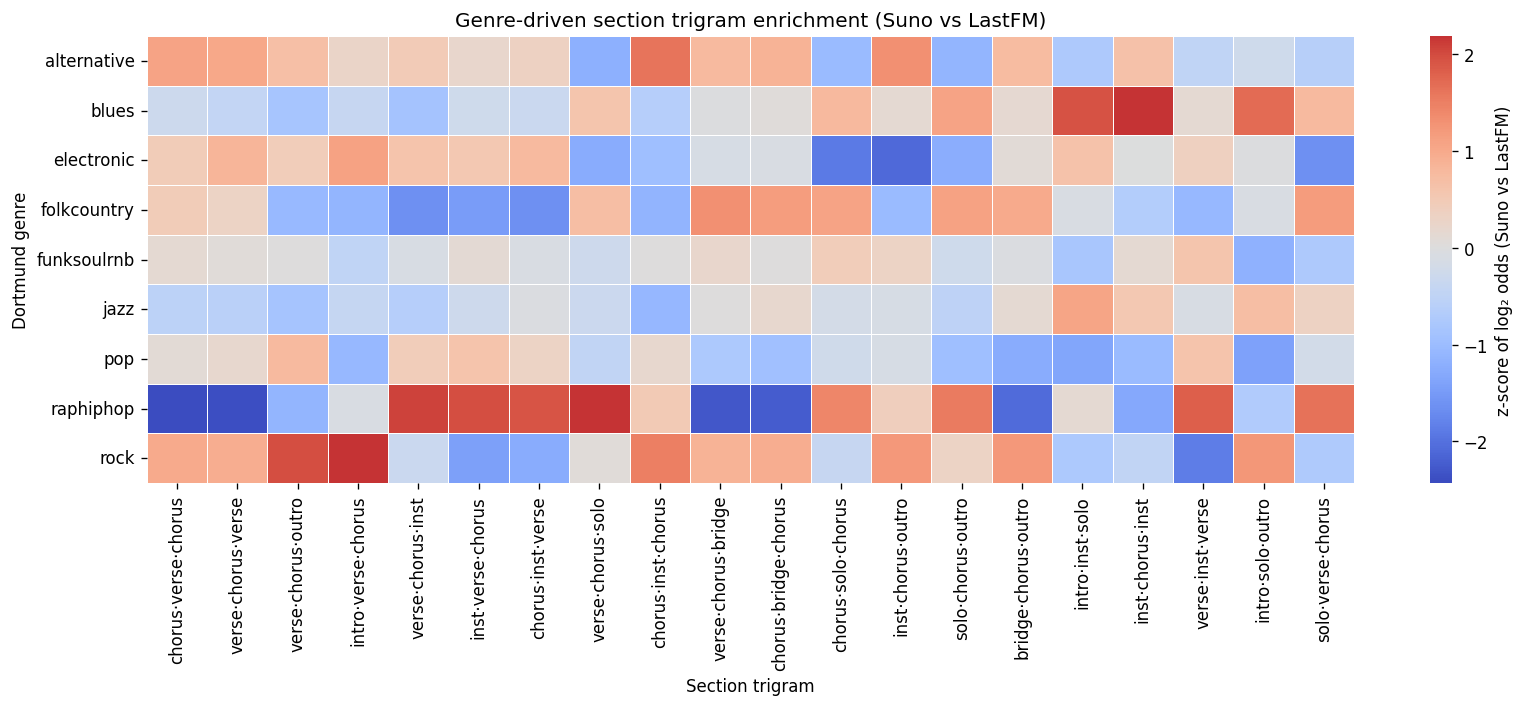

In [7]:
# Build genre-trigram matrix using Dortmund genres
N_heat = 20
top_tris_suno = [tuple(e['ngram']) for e in trigram_datasets['suno'][:N_heat]]

# Collect genre weights per trigram, per collection
genre_tri_weight = defaultdict(lambda: defaultdict(float))  # (genre, collection) -> {trigram: weight}
genre_total = defaultdict(float)  # (genre, collection) -> total

for collection in ['suno', 'lastfm']:
    for e in trigram_datasets[collection]:
        tri = tuple(e['ngram'])
        for genre, weight in e['dortmund_genres']:
            g = genre.lower()
            genre_tri_weight[(g, collection)][tri] += weight
            genre_total[(g, collection)] += weight

# Build log-odds matrix
genres = sorted({g for (g, c) in genre_tri_weight if c in ('suno', 'lastfm')})
mat = []
for g in genres:
    cs_ctr = genre_tri_weight.get((g, 'suno'), {})
    cl_ctr = genre_tri_weight.get((g, 'lastfm'), {})
    cs_tot = genre_total.get((g, 'suno'), 0)
    cl_tot = genre_total.get((g, 'lastfm'), 0)
    vals = []
    for tri in top_tris_suno:
        cs = cs_ctr.get(tri, 0)
        cl = cl_ctr.get(tri, 0)
        lor = np.log2(((cs + 0.5) / (cs_tot - cs + 0.5)) /
                      ((cl + 0.5) / (cl_tot - cl + 0.5)))
        vals.append(lor)
    mat.append(vals)

H = pd.DataFrame(mat, index=genres,
                 columns=['·'.join(t) for t in top_tris_suno])
H_z = (H - H.mean()) / H.std(ddof=0)

plt.figure(figsize=(14, 6), dpi=120)
sns.heatmap(H_z, cmap='coolwarm', center=0, linewidths=.5,
            cbar_kws=dict(label='z-score of log₂ odds (Suno vs LastFM)'))
plt.title('Genre-driven section trigram enrichment (Suno vs LastFM)')
plt.ylabel('Dortmund genre')
plt.xlabel('Section trigram')
plt.tight_layout()
plt.savefig('../Figures/musical_form_genre_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 8. Byte-Pair Encoding (BPE) of Musical Form Trigrams

Each song's section sequence yields a sequence of **trigrams** (overlapping windows of 3 sections). BPE then treats each trigram as a token and iteratively merges the most frequent adjacent trigram-pairs — discovering which trigram combinations systematically co-occur across songs.

In [8]:
# ---- BPE engine (operates on trigram-token sequences) ----

def get_pair_frequencies(sequences):
    pair_freq = Counter()
    for seq in sequences:
        for i in range(len(seq) - 1):
            pair_freq[(seq[i], seq[i + 1])] += 1
    return pair_freq

def merge_pair(sequences, pair_to_merge, new_token):
    merged = []
    for seq in sequences:
        new_seq = []
        i = 0
        while i < len(seq):
            if i < len(seq) - 1 and (seq[i], seq[i + 1]) == pair_to_merge:
                new_seq.append(new_token)
                i += 2
            else:
                new_seq.append(seq[i])
                i += 1
        merged.append(tuple(new_seq))
    return merged

def expand_token(token, merge_rules):
    if token not in merge_rules:
        return [token]
    a, b = merge_rules[token]
    return expand_token(a, merge_rules) + expand_token(b, merge_rules)

def byte_pair_encoding(sequences, num_merges=100):
    merge_rules = {}
    merge_history = []
    token_index = 0
    for _ in range(num_merges):
        pair_freq = get_pair_frequencies(sequences)
        if not pair_freq:
            break
        best_pair, freq = pair_freq.most_common(1)[0]
        new_token = f'M{token_index}'
        token_index += 1
        merge_history.append((best_pair, freq))
        sequences = merge_pair(sequences, best_pair, new_token)
        merge_rules[new_token] = best_pair
    return merge_rules, merge_history, sequences

def expand_pattern(token, merge_rules):
    """Expand a BPE token back to the original trigrams it represents."""
    return expand_token(token, merge_rules)

def trigram_str(tri):
    """Pretty-print a trigram token: 'verse·chorus·verse'"""
    if isinstance(tri, tuple):
        return '·'.join(tri)
    return str(tri)

print('BPE engine ready (operates on trigram tokens).')

BPE engine ready (operates on trigram tokens).


In [9]:
# ---- Build trigram-token sequences per song, then run BPE ----
NUM_MERGES = 80

bpe_results = {}  # collection -> (merge_rules, merge_history, patterns)

for collection in COLLECTIONS:
    # Each song -> sequence of trigram tokens
    trigram_sequences = []
    for _, sections, _, _ in collection_data[collection]:
        filtered = collapse_repeats([s for s in sections if s not in ('start', 'end')])
        if len(filtered) < 3:
            continue
        # Build overlapping trigrams as tokens (tuples)
        tri_seq = []
        for i in range(len(filtered) - 2):
            tri_seq.append(tuple(filtered[i:i+3]))
        if len(tri_seq) >= 2:
            trigram_sequences.append(tuple(tri_seq))
    
    print(f'\n{collection.upper()}: {len(trigram_sequences)} songs with ≥2 trigrams')
    
    # Stats
    lengths = [len(s) for s in trigram_sequences]
    print(f'  Mean trigram-sequence length: {np.mean(lengths):.1f} trigrams/song')
    
    # Count unique trigram types used as tokens
    all_tri_tokens = Counter()
    for seq in trigram_sequences:
        all_tri_tokens.update(seq)
    print(f'  Unique trigram types: {len(all_tri_tokens)}')
    print(f'  Top 5 trigrams: {[trigram_str(t) for t, _ in all_tri_tokens.most_common(5)]}')
    
    rules, history, merged_seqs = byte_pair_encoding(trigram_sequences, num_merges=NUM_MERGES)
    
    # Expand patterns back to original trigrams
    patterns = []
    for (a, b), freq in history[:30]:
        tok = [k for k, v in rules.items() if v == (a, b)]
        if tok:
            expanded = expand_token(tok[0], rules)
            patterns.append((expanded, freq))
    
    bpe_results[collection] = (rules, history, patterns)
    
    print(f'  Top 15 BPE merged trigram-patterns:')
    for i, (pat, freq) in enumerate(patterns[:15]):
        readable = ' | '.join(trigram_str(t) for t in pat)
        print(f'    {i+1:2d}. [{readable}]  freq={freq:,}')


LASTFM: 17694 songs with ≥2 trigrams
  Mean trigram-sequence length: 5.9 trigrams/song
  Unique trigram types: 317
  Top 5 trigrams: ['chorus·verse·chorus', 'verse·chorus·verse', 'intro·verse·chorus', 'verse·chorus·solo', 'verse·chorus·inst']
  Top 15 BPE merged trigram-patterns:
     1. [verse·chorus·verse | chorus·verse·chorus]  freq=9,621
     2. [intro·verse·chorus | verse·chorus·verse | chorus·verse·chorus]  freq=5,143
     3. [chorus·inst·verse | inst·verse·chorus]  freq=2,757
     4. [verse·chorus·inst | chorus·inst·verse | inst·verse·chorus]  freq=2,371
     5. [verse·chorus·bridge | chorus·bridge·chorus]  freq=2,272
     6. [verse·chorus·solo | chorus·solo·chorus]  freq=1,963
     7. [verse·chorus·solo | chorus·solo·verse]  freq=1,738
     8. [verse·chorus·solo | chorus·solo·verse | solo·verse·chorus]  freq=1,481
     9. [intro·verse·chorus | verse·chorus·inst | chorus·inst·verse | inst·verse·chorus]  freq=1,231
    10. [verse·chorus·inst | chorus·inst·chorus]  freq=1,166
   

## 9. BPE Trigram-Pattern Heatmap (Cross-Collection)

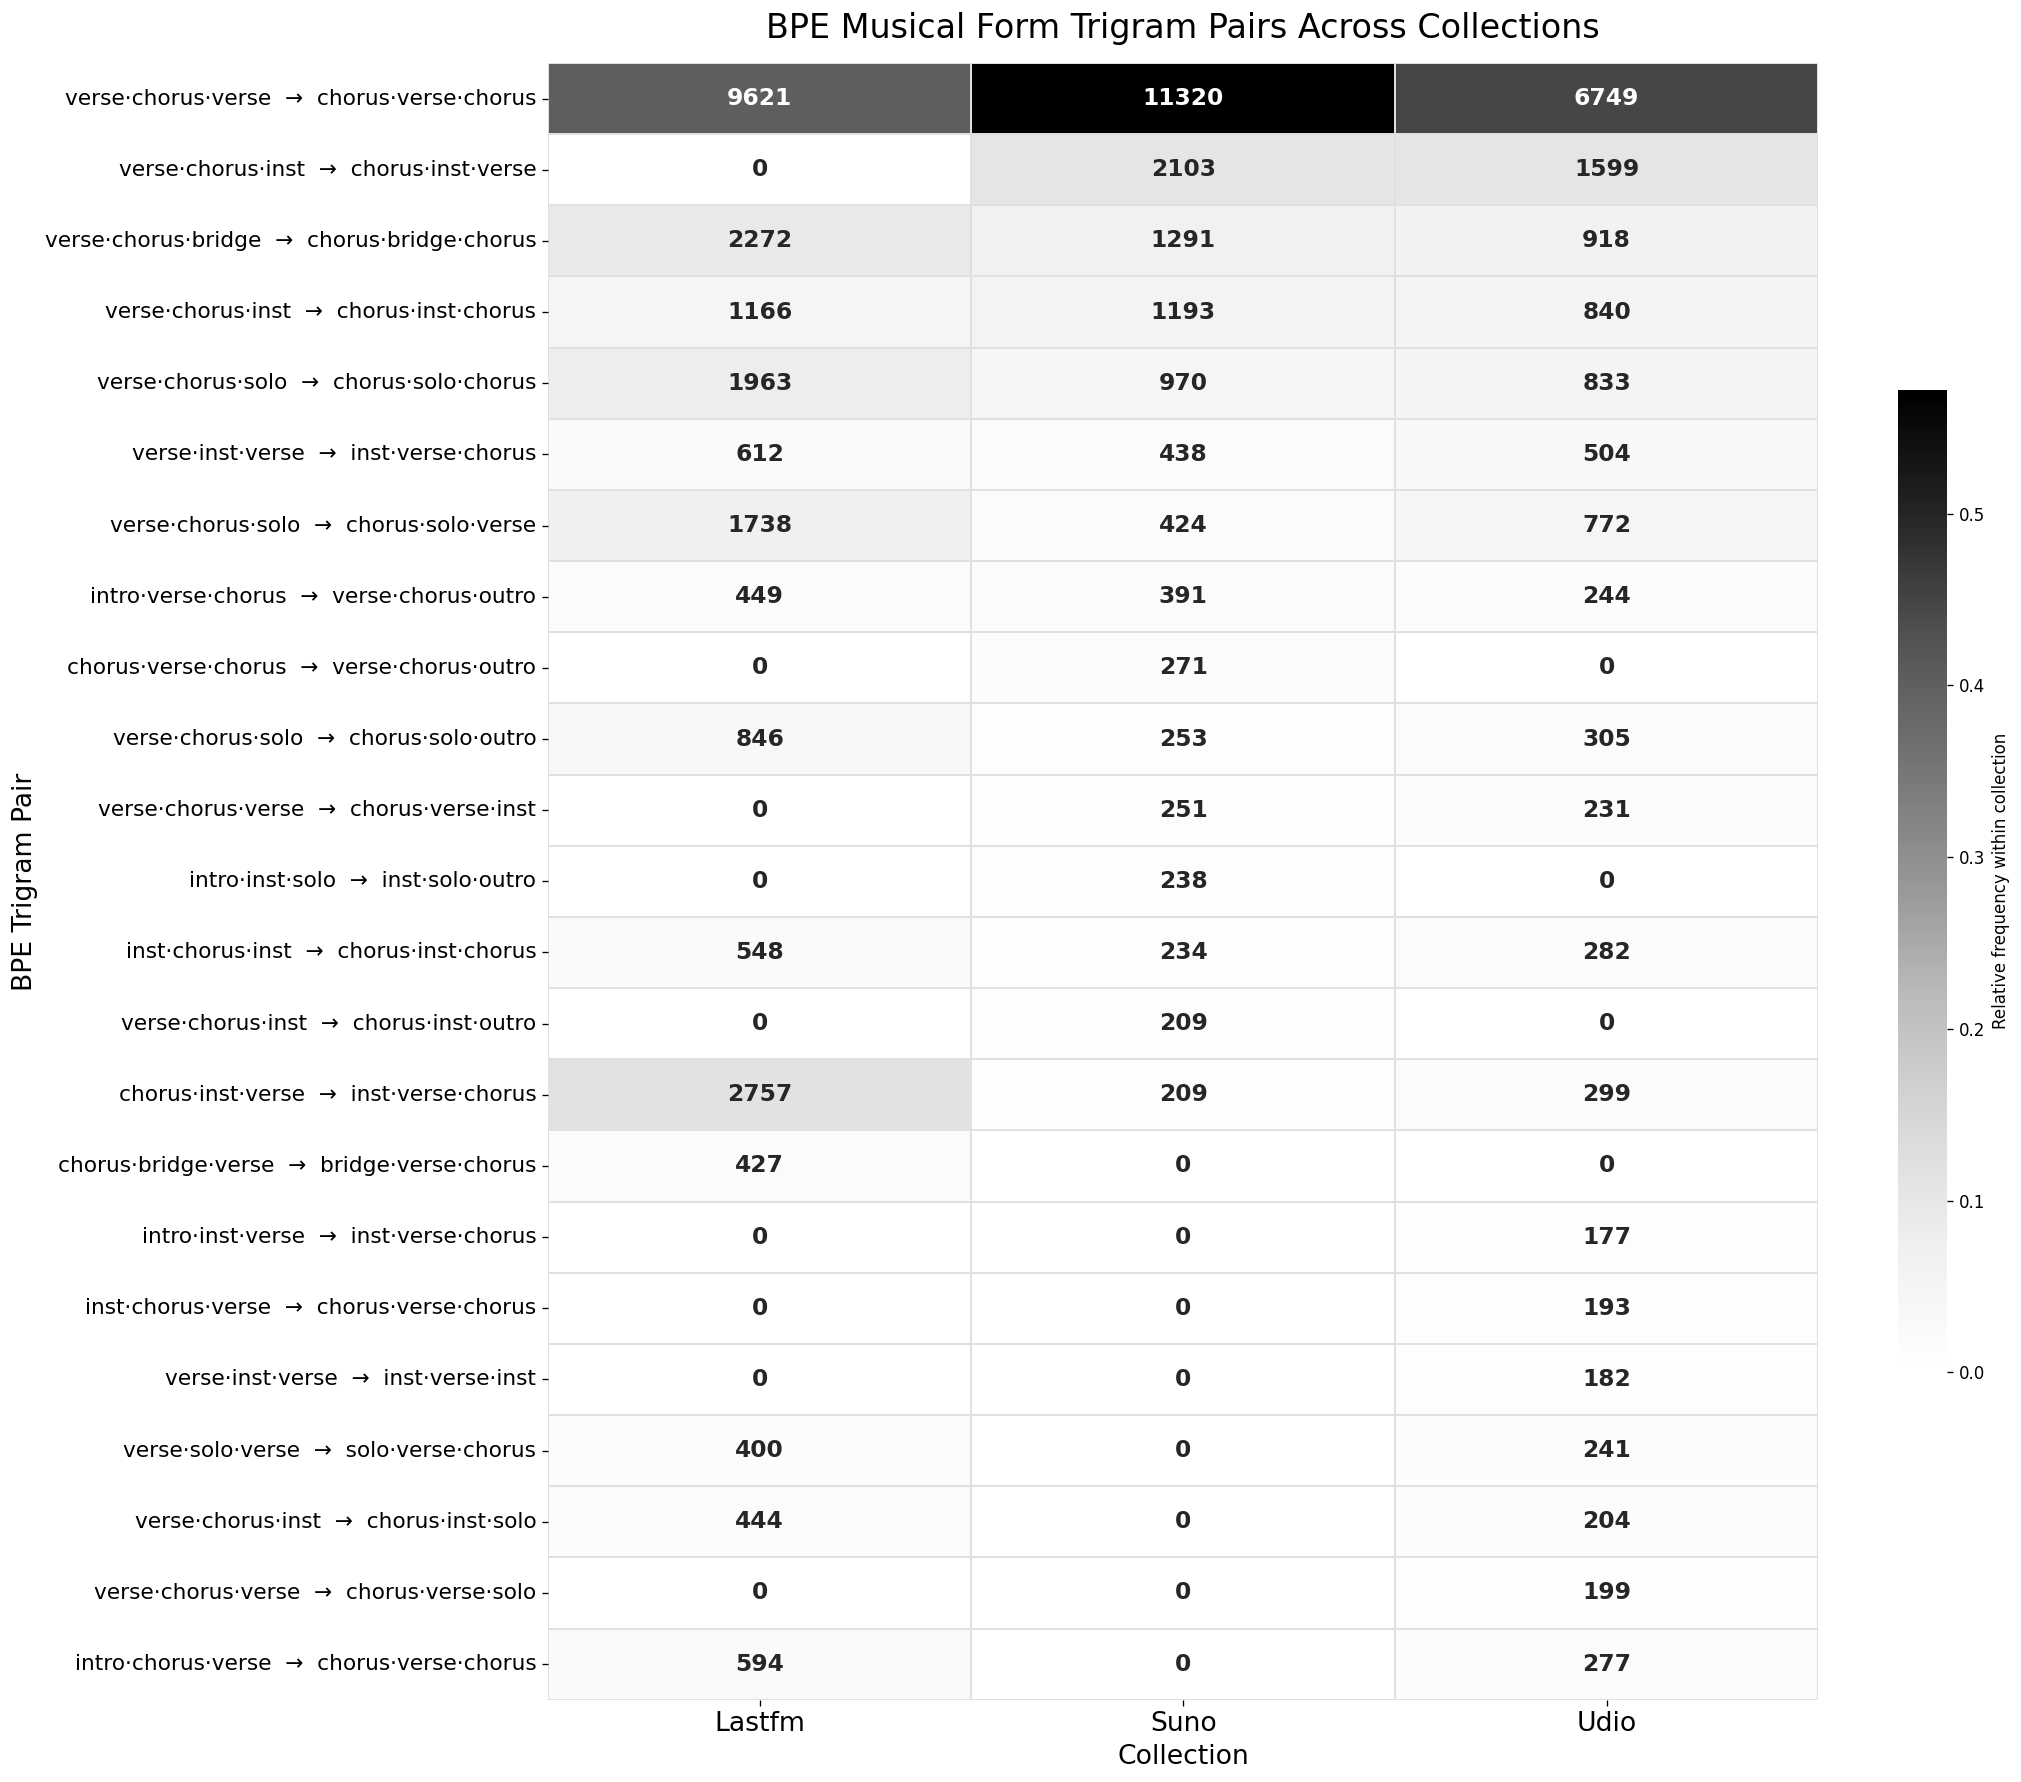

In [10]:
# Collect BPE trigram PAIRS only (len==2) across collections
N_patterns = 30  # look deeper since we filter for pairs
all_patterns = set()
for col in COLLECTIONS:
    for pat, _ in bpe_results[col][2][:N_patterns]:
        pat_norm = tuple(tuple(x) if isinstance(x, tuple) else (x,) for x in pat)
        if len(pat_norm) == 2:  # only keep direct bigram pairs
            all_patterns.add(pat_norm)

# Sort by Suno frequency (descending)
def pattern_suno_freq(pat):
    for pat2, freq in bpe_results['suno'][2]:
        p2 = tuple(tuple(x) if isinstance(x, tuple) else (x,) for x in pat2)
        if p2 == pat:
            return freq
    return 0

pattern_list = sorted(all_patterns, key=pattern_suno_freq, reverse=True)

# Build frequency matrix
freq_matrix = np.zeros((len(pattern_list), len(COLLECTIONS)))
for i, pat in enumerate(pattern_list):
    for j, col in enumerate(COLLECTIONS):
        for p, freq in bpe_results[col][2]:
            p_norm = tuple(tuple(x) if isinstance(x, tuple) else (x,) for x in p)
            if p_norm == pat:
                freq_matrix[i, j] = freq
                break

# Normalize per collection
col_totals = freq_matrix.sum(axis=0, keepdims=True)
col_totals[col_totals == 0] = 1
freq_norm = freq_matrix / col_totals

# Labels: show exactly 2 trigrams per row
def pattern_label(pat):
    return '·'.join(pat[0]) + '  →  ' + '·'.join(pat[1])

y_labels = [pattern_label(p) for p in pattern_list]

n_patterns = len(pattern_list)
fig, ax = plt.subplots(figsize=(18, max(10, n_patterns * 0.65)), dpi=120)
sns.heatmap(
    freq_norm,
    ax=ax,
    xticklabels=[c.capitalize() for c in COLLECTIONS],
    yticklabels=y_labels,
    cmap='Greys',
    linewidths=1,
    linecolor='#E0E0E0',
    annot=freq_matrix.astype(int),
    fmt='d',
    annot_kws={'fontsize': 14, 'fontweight': 'bold'},
    cbar_kws={'label': 'Relative frequency within collection', 'shrink': 0.6}
)
ax.set_xlabel('Collection', fontsize=16)
ax.set_ylabel('BPE Trigram Pair', fontsize=16)
ax.set_title('BPE Musical Form Trigram Pairs Across Collections', fontsize=20, pad=15)
ax.tick_params(axis='y', labelsize=13)
ax.tick_params(axis='x', labelsize=16)
plt.tight_layout()
plt.savefig('../Figures/musical_form_bpe_trigram_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Cross-Collection Correlation — Musical Form Trigram Pairs

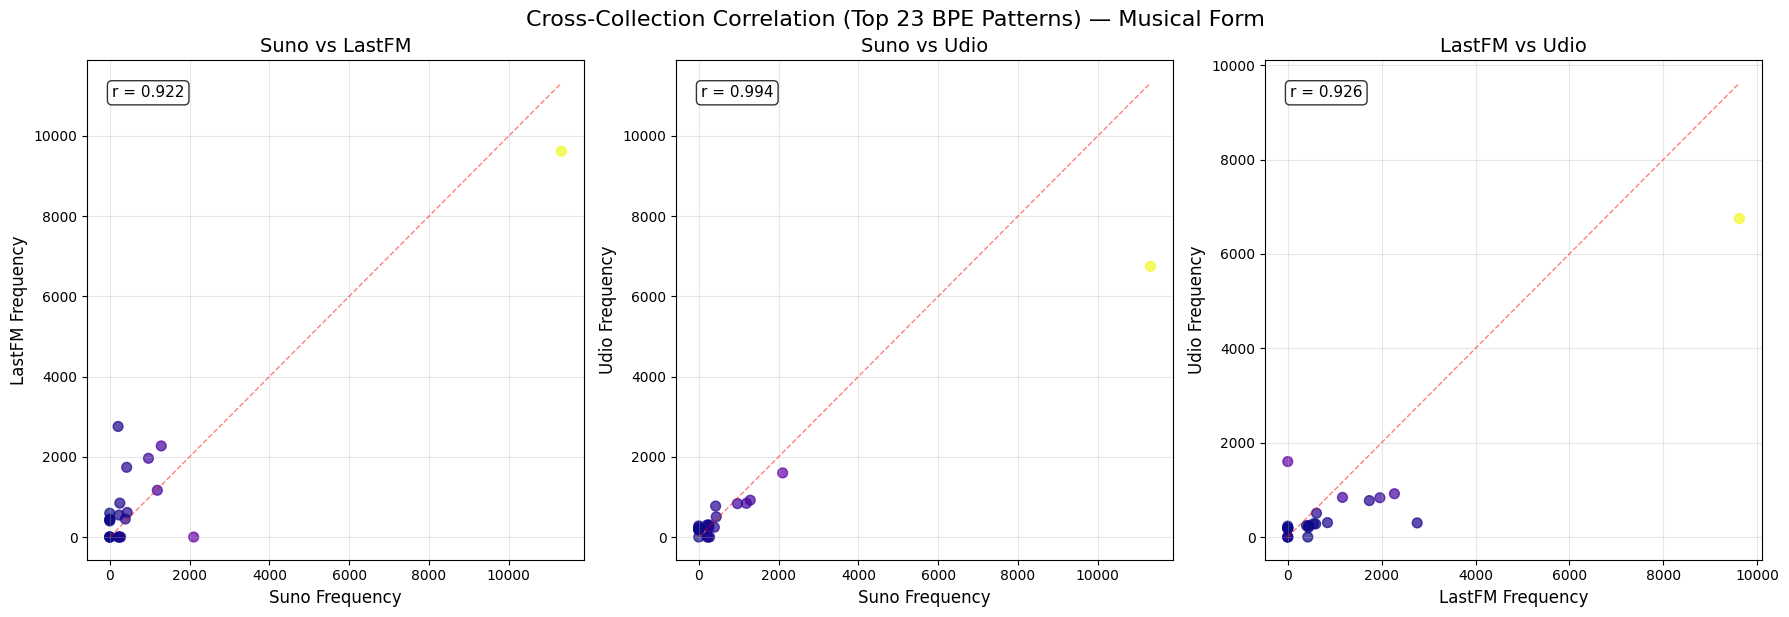


Most divergent patterns (high in one, low in others):
verse·chorus·verse  →  chorus·verse·chorus    | CV: 0.20 | Dominant: suno (11320)
verse·chorus·inst  →  chorus·inst·verse       | CV: 0.73 | Dominant: suno (2103)
verse·chorus·bridge  →  chorus·bridge·chorus  | CV: 0.38 | Dominant: lastfm (2272)
verse·chorus·inst  →  chorus·inst·chorus      | CV: 0.15 | Dominant: suno (1193)
verse·chorus·solo  →  chorus·solo·chorus      | CV: 0.40 | Dominant: lastfm (1963)
verse·inst·verse  →  inst·verse·chorus        | CV: 0.14 | Dominant: lastfm (612)
verse·chorus·solo  →  chorus·solo·verse       | CV: 0.57 | Dominant: lastfm (1738)
intro·verse·chorus  →  verse·chorus·outro     | CV: 0.24 | Dominant: lastfm (449)
chorus·verse·chorus  →  verse·chorus·outro    | CV: 1.41 | Dominant: suno (271)
verse·chorus·solo  →  chorus·solo·outro       | CV: 0.57 | Dominant: lastfm (846)

Consistent patterns (similar frequencies across all collections):
verse·chorus·verse  →  chorus·verse·chorus    | LastFM: 962

In [11]:
# Scatter plot: cross-collection correlation analysis

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

lastfm_freqs = freq_matrix[:, 0]
suno_freqs = freq_matrix[:, 1]
udio_freqs = freq_matrix[:, 2]

comparisons = [
    (suno_freqs, lastfm_freqs, 'Suno vs LastFM', 'Suno Frequency', 'LastFM Frequency'),
    (suno_freqs, udio_freqs, 'Suno vs Udio', 'Suno Frequency', 'Udio Frequency'),
    (lastfm_freqs, udio_freqs, 'LastFM vs Udio', 'LastFM Frequency', 'Udio Frequency')
]

for i, (x_data, y_data, title, xlabel, ylabel) in enumerate(comparisons):
    ax = axes[i]
    scatter = ax.scatter(x_data, y_data, alpha=0.7, s=50, c=suno_freqs, cmap='plasma')
    max_val = max(max(x_data), max(y_data))
    ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, linewidth=1)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.grid(True, alpha=0.3)
    correlation = np.corrcoef(x_data, y_data)[0, 1]
    ax.text(0.05, 0.95, f'r = {correlation:.3f}', transform=ax.transAxes,
            fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.suptitle(f'Cross-Collection Correlation (Top {len(pattern_list)} BPE Patterns) — Musical Form', fontsize=16, y=1.02)
plt.savefig('../Figures/musical_form_bpe_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

# Most divergent patterns
print('\nMost divergent patterns (high in one, low in others):')
for i, pair in enumerate(y_labels[:10]):
    lastfm, suno, udio = freq_matrix[i]
    freqs_arr = [lastfm, suno, udio]
    if sum(freqs_arr) > 0:
        cv = np.std(freqs_arr) / np.mean(freqs_arr)
        max_col = COLLECTIONS[np.argmax(freqs_arr)]
        print(f'{pair:<45} | CV: {cv:.2f} | Dominant: {max_col} ({max(freqs_arr):.0f})')

print('\nConsistent patterns (similar frequencies across all collections):')
count = 0
for i, pair in enumerate(y_labels):
    lastfm, suno, udio = freq_matrix[i]
    if min(lastfm, suno, udio) > 50:
        cv = np.std([lastfm, suno, udio]) / np.mean([lastfm, suno, udio])
        if cv < 0.5:
            print(f'{pair:<45} | LastFM: {lastfm:.0f}, Suno: {suno:.0f}, Udio: {udio:.0f}')
            count += 1
            if count >= 5:
                break

## 11. Full Song Structure Distributions

In [12]:
# Most common full section sequences (collapsed consecutive duplicates)
def collapse_repeats(sections):
    """Collapse consecutive identical sections: [verse, verse, chorus] -> [verse, chorus]"""
    if not sections:
        return []
    result = [sections[0]]
    for s in sections[1:]:
        if s != result[-1]:
            result.append(s)
    return result

N_forms = 20
for collection in COLLECTIONS:
    form_counter = Counter()
    for _, sections, _, _ in collection_data[collection]:
        # Remove start/end, collapse repeats
        filtered = [s for s in sections if s not in ('start', 'end')]
        collapsed = tuple(collapse_repeats(filtered))
        form_counter[collapsed] += 1
    
    print(f'\n{collection.upper()} — Top {N_forms} full song forms (collapsed):')
    print(f'  Unique forms: {len(form_counter)}')
    for i, (form, count) in enumerate(form_counter.most_common(N_forms)):
        pct = count / sum(form_counter.values()) * 100
        print(f'  {i+1:2d}. ({count:5d}, {pct:4.1f}%)  {" → ".join(form)}')


LASTFM — Top 20 full song forms (collapsed):
  Unique forms: 6020
   1. (  643,  3.2%)  intro → verse → chorus → verse → chorus → outro
   2. (  516,  2.6%)  intro → verse → chorus → verse → chorus → bridge → chorus → outro
   3. (  396,  2.0%)  intro → verse → chorus → verse → chorus → verse → chorus → outro
   4. (  389,  2.0%)  intro → verse → chorus → verse → chorus → bridge → chorus
   5. (  319,  1.6%)  intro → solo → outro
   6. (  317,  1.6%)  intro
   7. (  300,  1.5%)  intro → verse → chorus → outro
   8. (  299,  1.5%)  intro → verse → chorus → verse → chorus
   9. (  290,  1.5%)  intro → verse → chorus → verse → chorus → solo → chorus → outro
  10. (  245,  1.2%)  intro → verse → chorus → inst → verse → chorus → outro
  11. (  226,  1.1%)  verse → chorus → verse → chorus → outro
  12. (  219,  1.1%)  verse → chorus → verse → chorus
  13. (  207,  1.0%)  verse → chorus → verse → chorus → bridge → chorus
  14. (  201,  1.0%)  intro → verse → chorus
  15. (  198,  1.0%)  intr

## 12. Section Transition Matrix

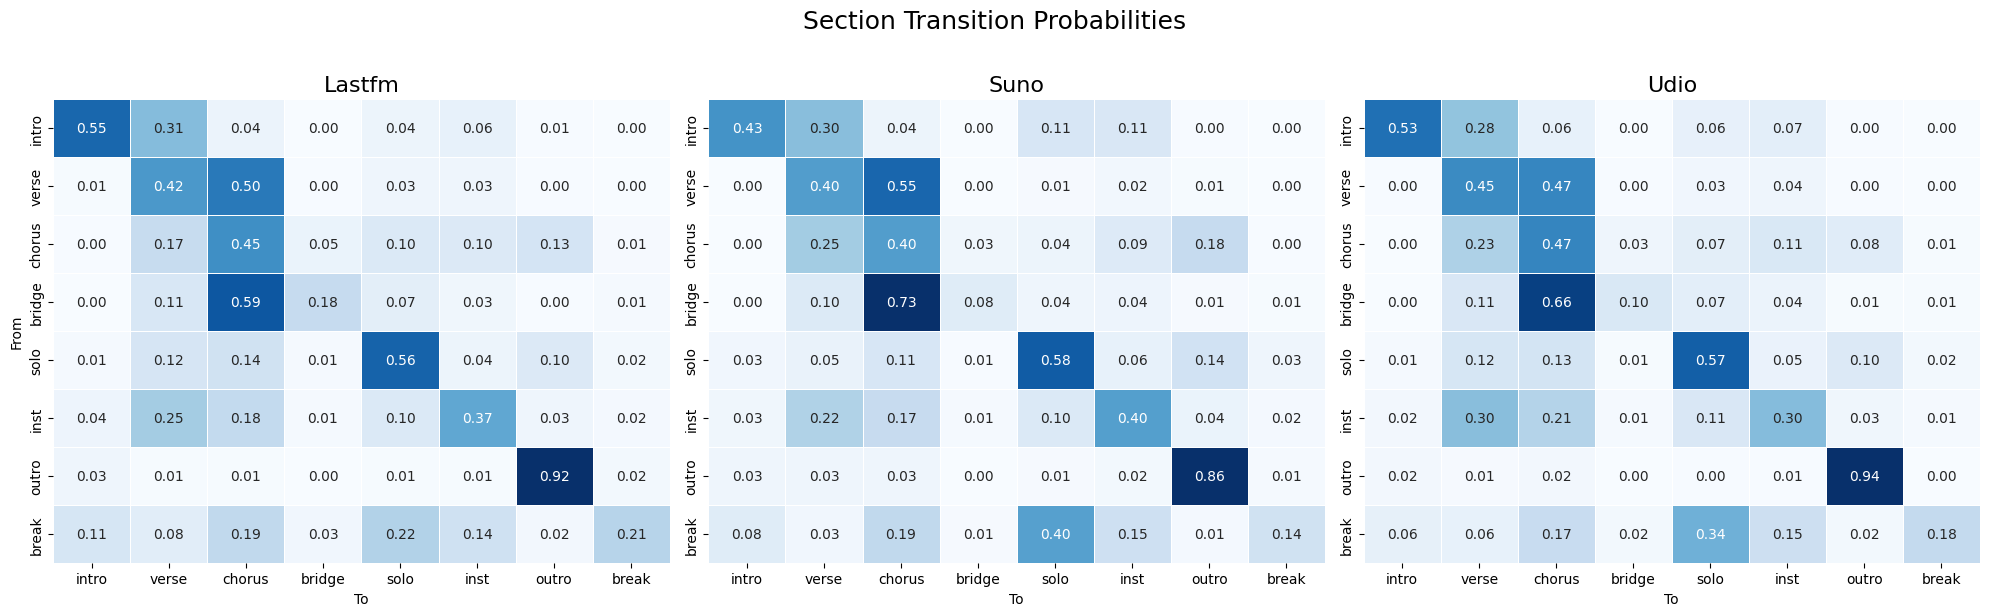

In [13]:
# Build section transition matrices per collection
SECTION_ORDER = ['intro', 'verse', 'chorus', 'bridge', 'solo', 'inst', 'outro', 'break']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, collection in zip(axes, COLLECTIONS):
    trans = defaultdict(Counter)
    for _, sections, _, _ in collection_data[collection]:
        filtered = [s for s in sections if s not in ('start', 'end')]
        for i in range(len(filtered) - 1):
            trans[filtered[i]][filtered[i + 1]] += 1
    
    # Build matrix
    labels = [s for s in SECTION_ORDER if s in trans or any(s in v for v in trans.values())]
    mat = np.zeros((len(labels), len(labels)))
    for i, src in enumerate(labels):
        row_total = sum(trans[src].values())
        for j, dst in enumerate(labels):
            mat[i, j] = trans[src][dst] / row_total if row_total > 0 else 0
    
    sns.heatmap(mat, ax=ax, xticklabels=labels, yticklabels=labels,
                cmap='Blues', annot=True, fmt='.2f', linewidths=0.5,
                vmin=0, vmax=0.7, cbar=False)
    ax.set_title(f'{collection.capitalize()}', fontsize=16)
    ax.set_ylabel('From' if collection == 'lastfm' else '')
    ax.set_xlabel('To')

plt.suptitle('Section Transition Probabilities', fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig('../Figures/musical_form_transitions.png', dpi=300, bbox_inches='tight')
plt.show()

## 14. Style Analysis of Musical Form

Aggregate musical-form trigrams by genre and compare trigram profiles across collections, following the same approach used for chord trigrams in `test_music_form.ipynb`.

1. **Human-annotated styles** — from the `original` field in `_style.json`
2. **Dortmund genres** — proportionally weighted from `genre_dortmund`

In [14]:
# ── Build trigram dataset by style (human-annotated) ──
from collections import Counter, defaultdict

# Build data_entries: one per song, with trigrams and style info
style_entries = []
for collection in COLLECTIONS:
    for song_id, sections, dortmund, human_styles in collection_data[collection]:
        # Remove start/end, collapse repeats, extract trigrams
        filtered = [s for s in sections if s not in ('start', 'end')]
        collapsed = collapse_repeats(filtered)
        trigrams = [tuple(collapsed[i:i+3]) for i in range(len(collapsed)-2)]
        if not trigrams:
            continue
        # Human styles
        for style in human_styles:
            style_entries.append({
                'collection': collection,
                'style': style,
                'trigrams': trigrams,
            })

# Top 8 human styles
style_counts = Counter(e['style'] for e in style_entries if e['style'])
top_styles = [s for s, _ in style_counts.most_common(8)]

# Aggregate trigrams per (style, collection)
trigram_counts_by_style = defaultdict(lambda: defaultdict(Counter))
for entry in style_entries:
    style = entry['style']
    if style not in top_styles:
        continue
    collection = entry['collection']
    for trigram in entry['trigrams']:
        trigram_counts_by_style[style][collection][trigram] += 1

# Build long-format DataFrame for plotting
all_rows = []
for style in top_styles:
    all_trigrams = Counter()
    for collection in COLLECTIONS:
        all_trigrams += trigram_counts_by_style[style][collection]
    top20_trigrams = [t for t, _ in all_trigrams.most_common(20)]
    for trigram in top20_trigrams:
        trigram_str = ' - '.join(trigram)
        for collection in COLLECTIONS:
            count = trigram_counts_by_style[style][collection][trigram]
            all_rows.append({
                'style': style,
                'trigram': trigram_str,
                'collection': collection,
                'count': count
            })
df_long = pd.DataFrame(all_rows)

# Normalize per style/collection
for style in df_long['style'].unique():
    for collection in COLLECTIONS:
        mask = (df_long['style'] == style) & (df_long['collection'] == collection)
        max_count = df_long.loc[mask, 'count'].max()
        if max_count > 0:
            df_long.loc[mask, 'normalized_count'] = df_long.loc[mask, 'count'] / max_count * 100
        else:
            df_long.loc[mask, 'normalized_count'] = 0

df_long['profile_ratio'] = df_long['normalized_count'] / 100

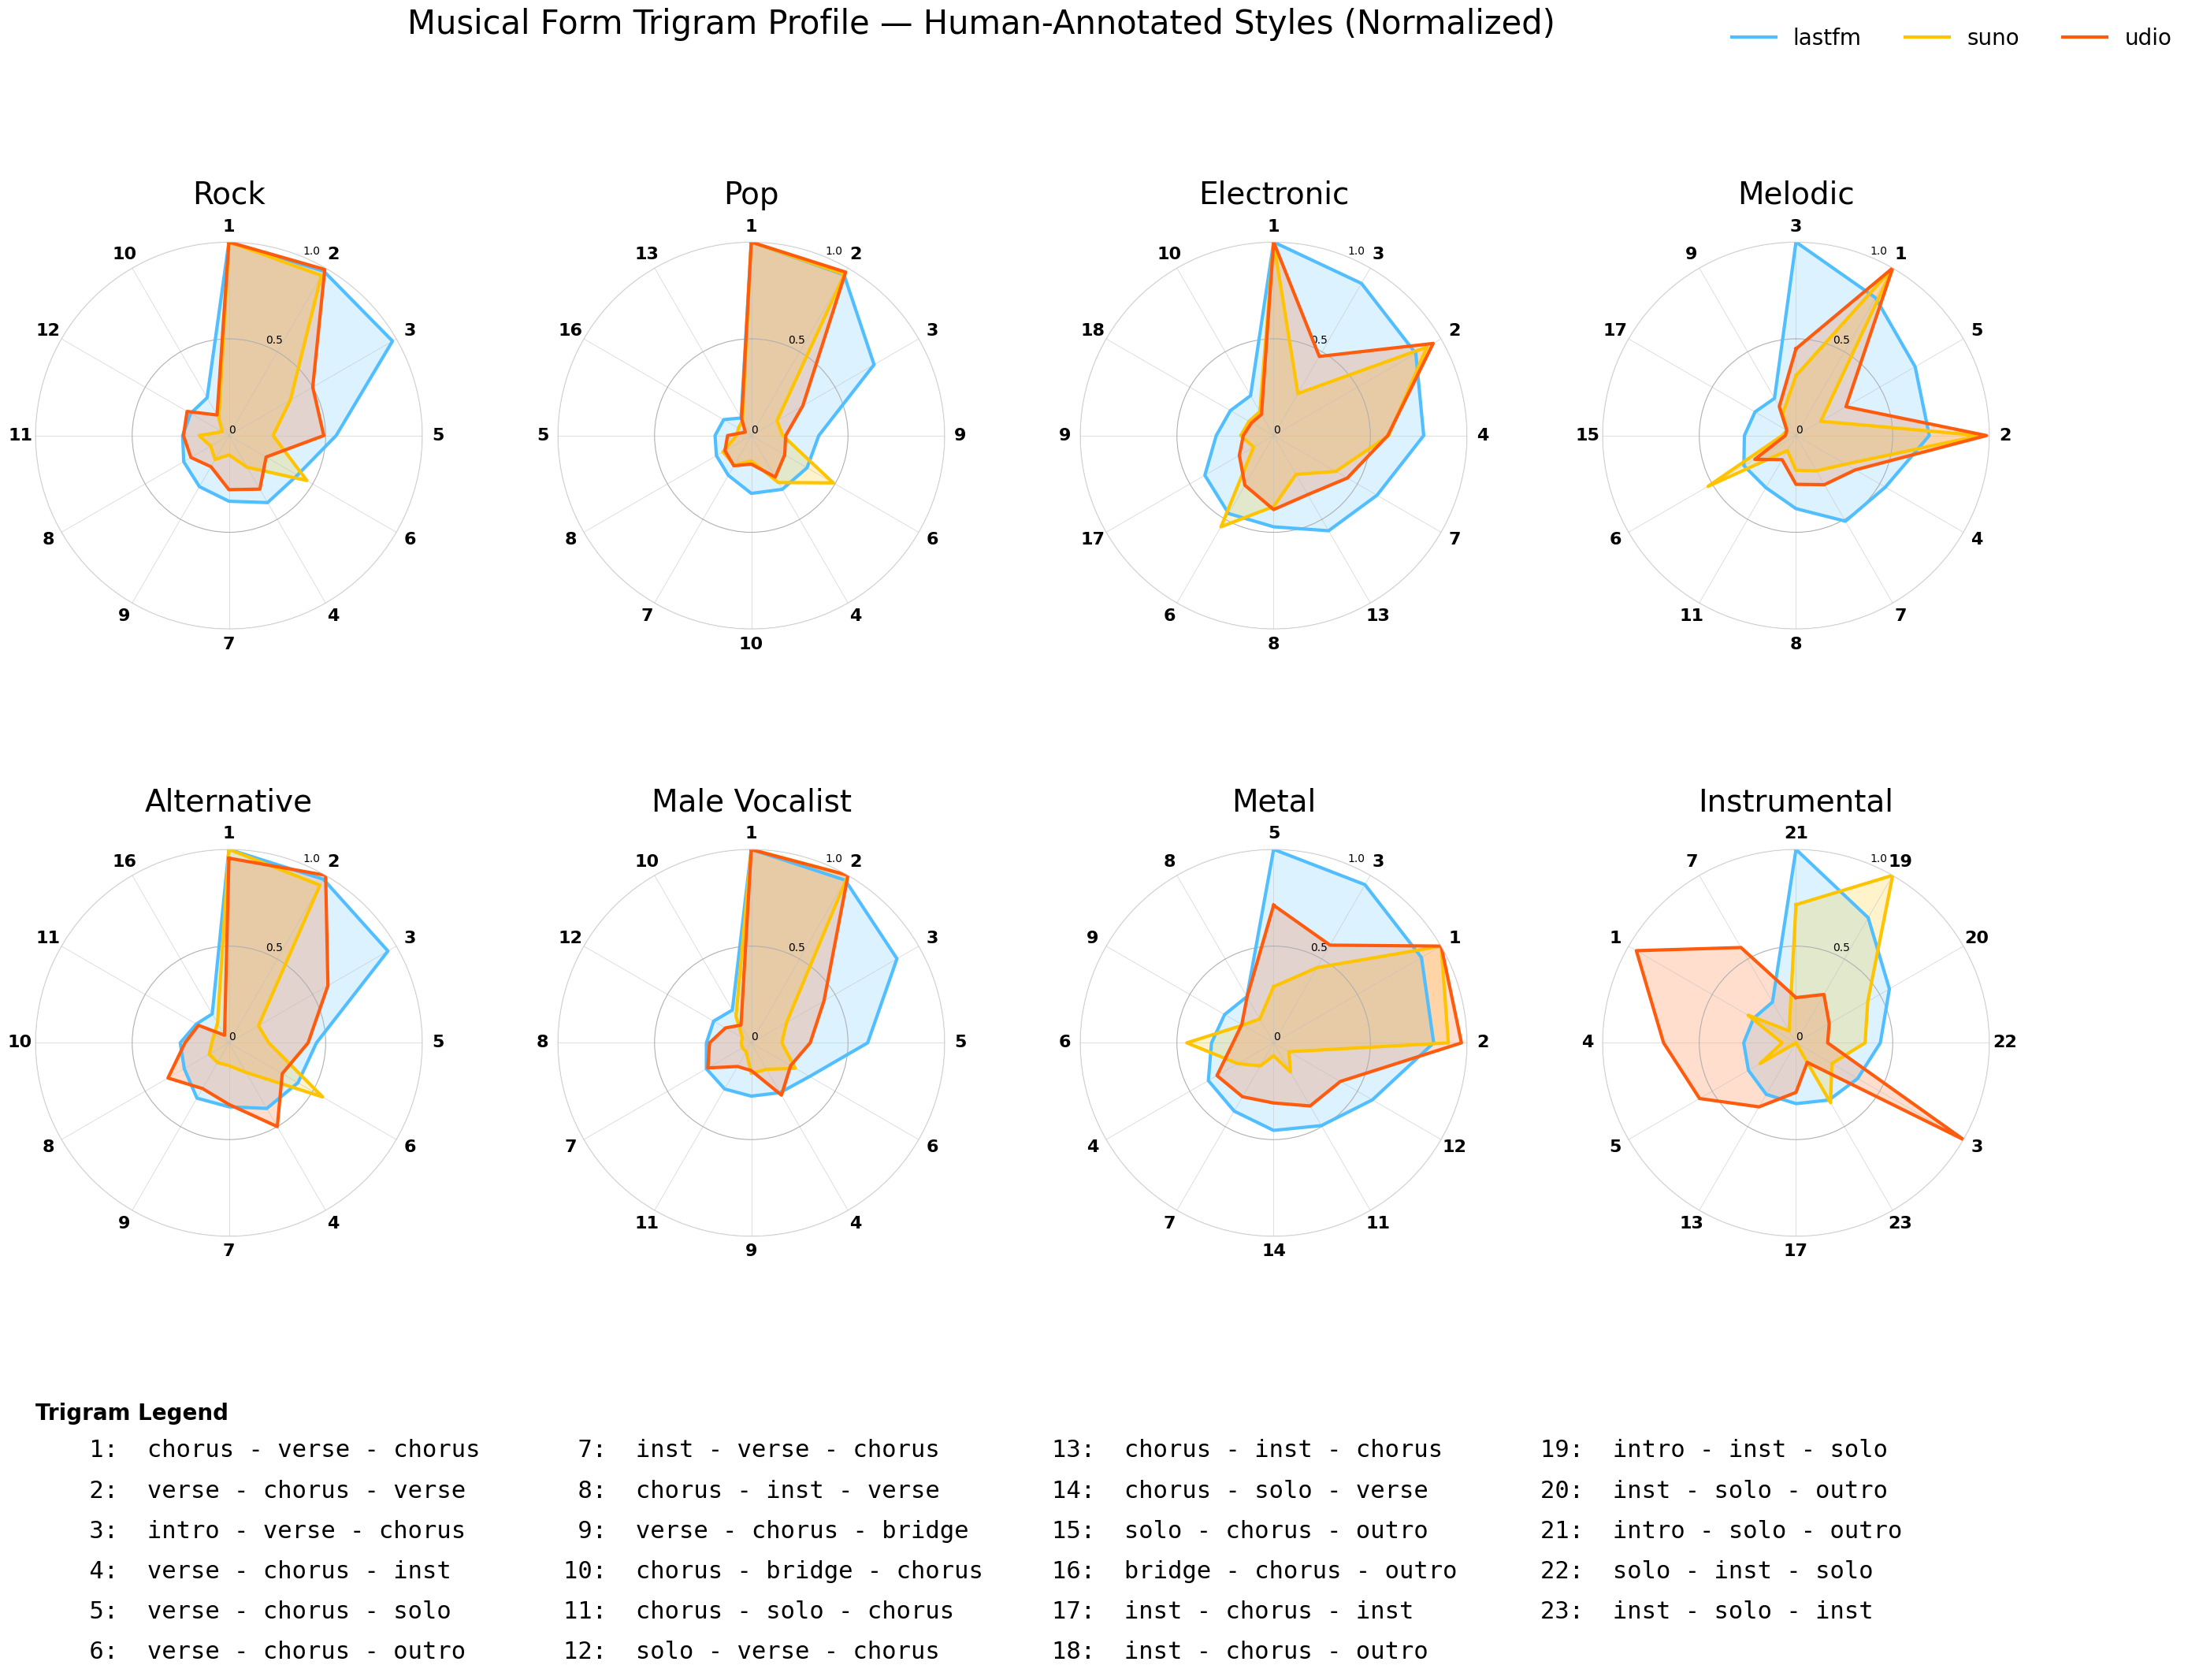

In [20]:
# ── Spider (Radar) chart for top trigrams per style (human-annotated) ──
# Global trigram numbering: one consistent number per unique trigram across all styles
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import numpy as np

N = 12  # Number of top trigrams to show per style
styles = df_long['style'].unique()
colors = [colors_coll[c] for c in COLLECTIONS]
reference_collection = 'lastfm'

# 1. Get top trigrams per style
trigram_order_per_style = {}
for style in styles:
    top_trigrams = (
        df_long[(df_long['style'] == style) & (df_long['collection'] == reference_collection)]
        .groupby('trigram')['count'].sum()
        .sort_values(ascending=False).head(N).index.tolist()
    )
    if len(top_trigrams) < N:
        all_top = (
            df_long[df_long['style'] == style]
            .groupby('trigram')['count'].sum()
            .sort_values(ascending=False).head(N).index.tolist()
        )
        for t in all_top:
            if t not in top_trigrams:
                top_trigrams.append(t)
            if len(top_trigrams) >= N:
                break
    trigram_order_per_style[style] = top_trigrams

# 2. Build global trigram → number mapping (ordered by overall frequency)
all_unique_trigrams = []
for style in styles:
    for t in trigram_order_per_style[style]:
        if t not in all_unique_trigrams:
            all_unique_trigrams.append(t)
global_freq = df_long.groupby('trigram')['count'].sum()
all_unique_trigrams.sort(key=lambda t: global_freq.get(t, 0), reverse=True)
global_trigram_num = {t: i+1 for i, t in enumerate(all_unique_trigrams)}

# 3. Layout: spider grid + legend row at bottom
n_styles = len(styles)
n_cols = 4
n_rows = int(np.ceil(n_styles / n_cols))
fig = plt.figure(figsize=(n_cols * 8, n_rows * 8 + 8))
gs = gridspec.GridSpec(n_rows + 1, n_cols, figure=fig,
                       height_ratios=[1]*n_rows + [0.55],
                       hspace=0.45, wspace=0.35)

# Spider subplots
axes = []
for r in range(n_rows):
    for c in range(n_cols):
        ax = fig.add_subplot(gs[r, c], polar=True)
        axes.append(ax)

for ax_idx, style in enumerate(styles):
    top_trigrams = trigram_order_per_style[style]
    num_vars = len(top_trigrams)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    axes[ax_idx].set_theta_offset(np.pi / 2)
    axes[ax_idx].set_theta_direction(-1)
    axes[ax_idx].spines['polar'].set_color("#D5D5D5")
    axes[ax_idx].spines['polar'].set_linewidth(1.0)
    axes[ax_idx].spines['polar'].set_alpha(0.5)

    for col, color in zip(COLLECTIONS, colors):
        subset = df_long[(df_long['style'] == style) & (df_long['collection'] == col)]
        subset = subset.set_index('trigram')
        data = [subset.loc[t, 'profile_ratio'] if t in subset.index else 0 for t in top_trigrams]
        data += data[:1]
        axes[ax_idx].plot(angles, data, color=color, label=col, linewidth=3)
        axes[ax_idx].fill(angles, data, color=color, alpha=0.2)

    axes[ax_idx].set_xticks(angles[:-1])
    axes[ax_idx].set_xticklabels([str(global_trigram_num[t]) for t in top_trigrams],
                                  fontsize=16, fontweight='bold')
    axes[ax_idx].set_yticks([0, 0.5, 1.0])
    axes[ax_idx].set_yticklabels(['0', '0.5', '1.0'])
    axes[ax_idx].set_ylim(0, 1)
    axes[ax_idx].xaxis.grid(True, color="#BFBFBF", linewidth=0.5, alpha=0.7)
    axes[ax_idx].set_title(f"{style.title()}", fontsize=28, pad=35)

# Remove unused spider axes
for ax in axes[len(styles):]:
    ax.set_visible(False)

# Collection legend (top-right area)
line_handles = [mlines.Line2D([], [], color=color, linewidth=3, label=col)
                for col, color in zip(COLLECTIONS, colors)]
fig.legend(handles=line_handles, labels=COLLECTIONS,
           loc='upper right', bbox_to_anchor=(0.98, 0.99), fontsize=20, frameon=False, ncol=3)

# Legend table at bottom
ax_legend = fig.add_subplot(gs[n_rows, :])
ax_legend.axis('off')

sorted_items = sorted(global_trigram_num.items(), key=lambda x: x[1])
n_items = len(sorted_items)
n_legend_cols = 4
rows_per_col = int(np.ceil(n_items / n_legend_cols))

for idx, (trigram, num) in enumerate(sorted_items):
    col_idx = idx // rows_per_col
    row_idx = idx % rows_per_col
    x = col_idx / n_legend_cols + 0.02
    y = 1.0 - (row_idx + 0.5) / rows_per_col
    ax_legend.text(x, y, f"{num:>2d}:  {trigram}", fontsize=22, family='monospace',
                   va='center', ha='left', transform=ax_legend.transAxes)

ax_legend.set_title("Trigram Legend", fontsize=20, fontweight='bold', loc='left', pad=10)
plt.suptitle("Musical Form Trigram Profile — Human-Annotated Styles (Normalized)", fontsize=30, y=0.99)
plt.savefig('../Figures/musical_form_trigram_styles_spider.png', dpi=300, bbox_inches='tight')
plt.show()

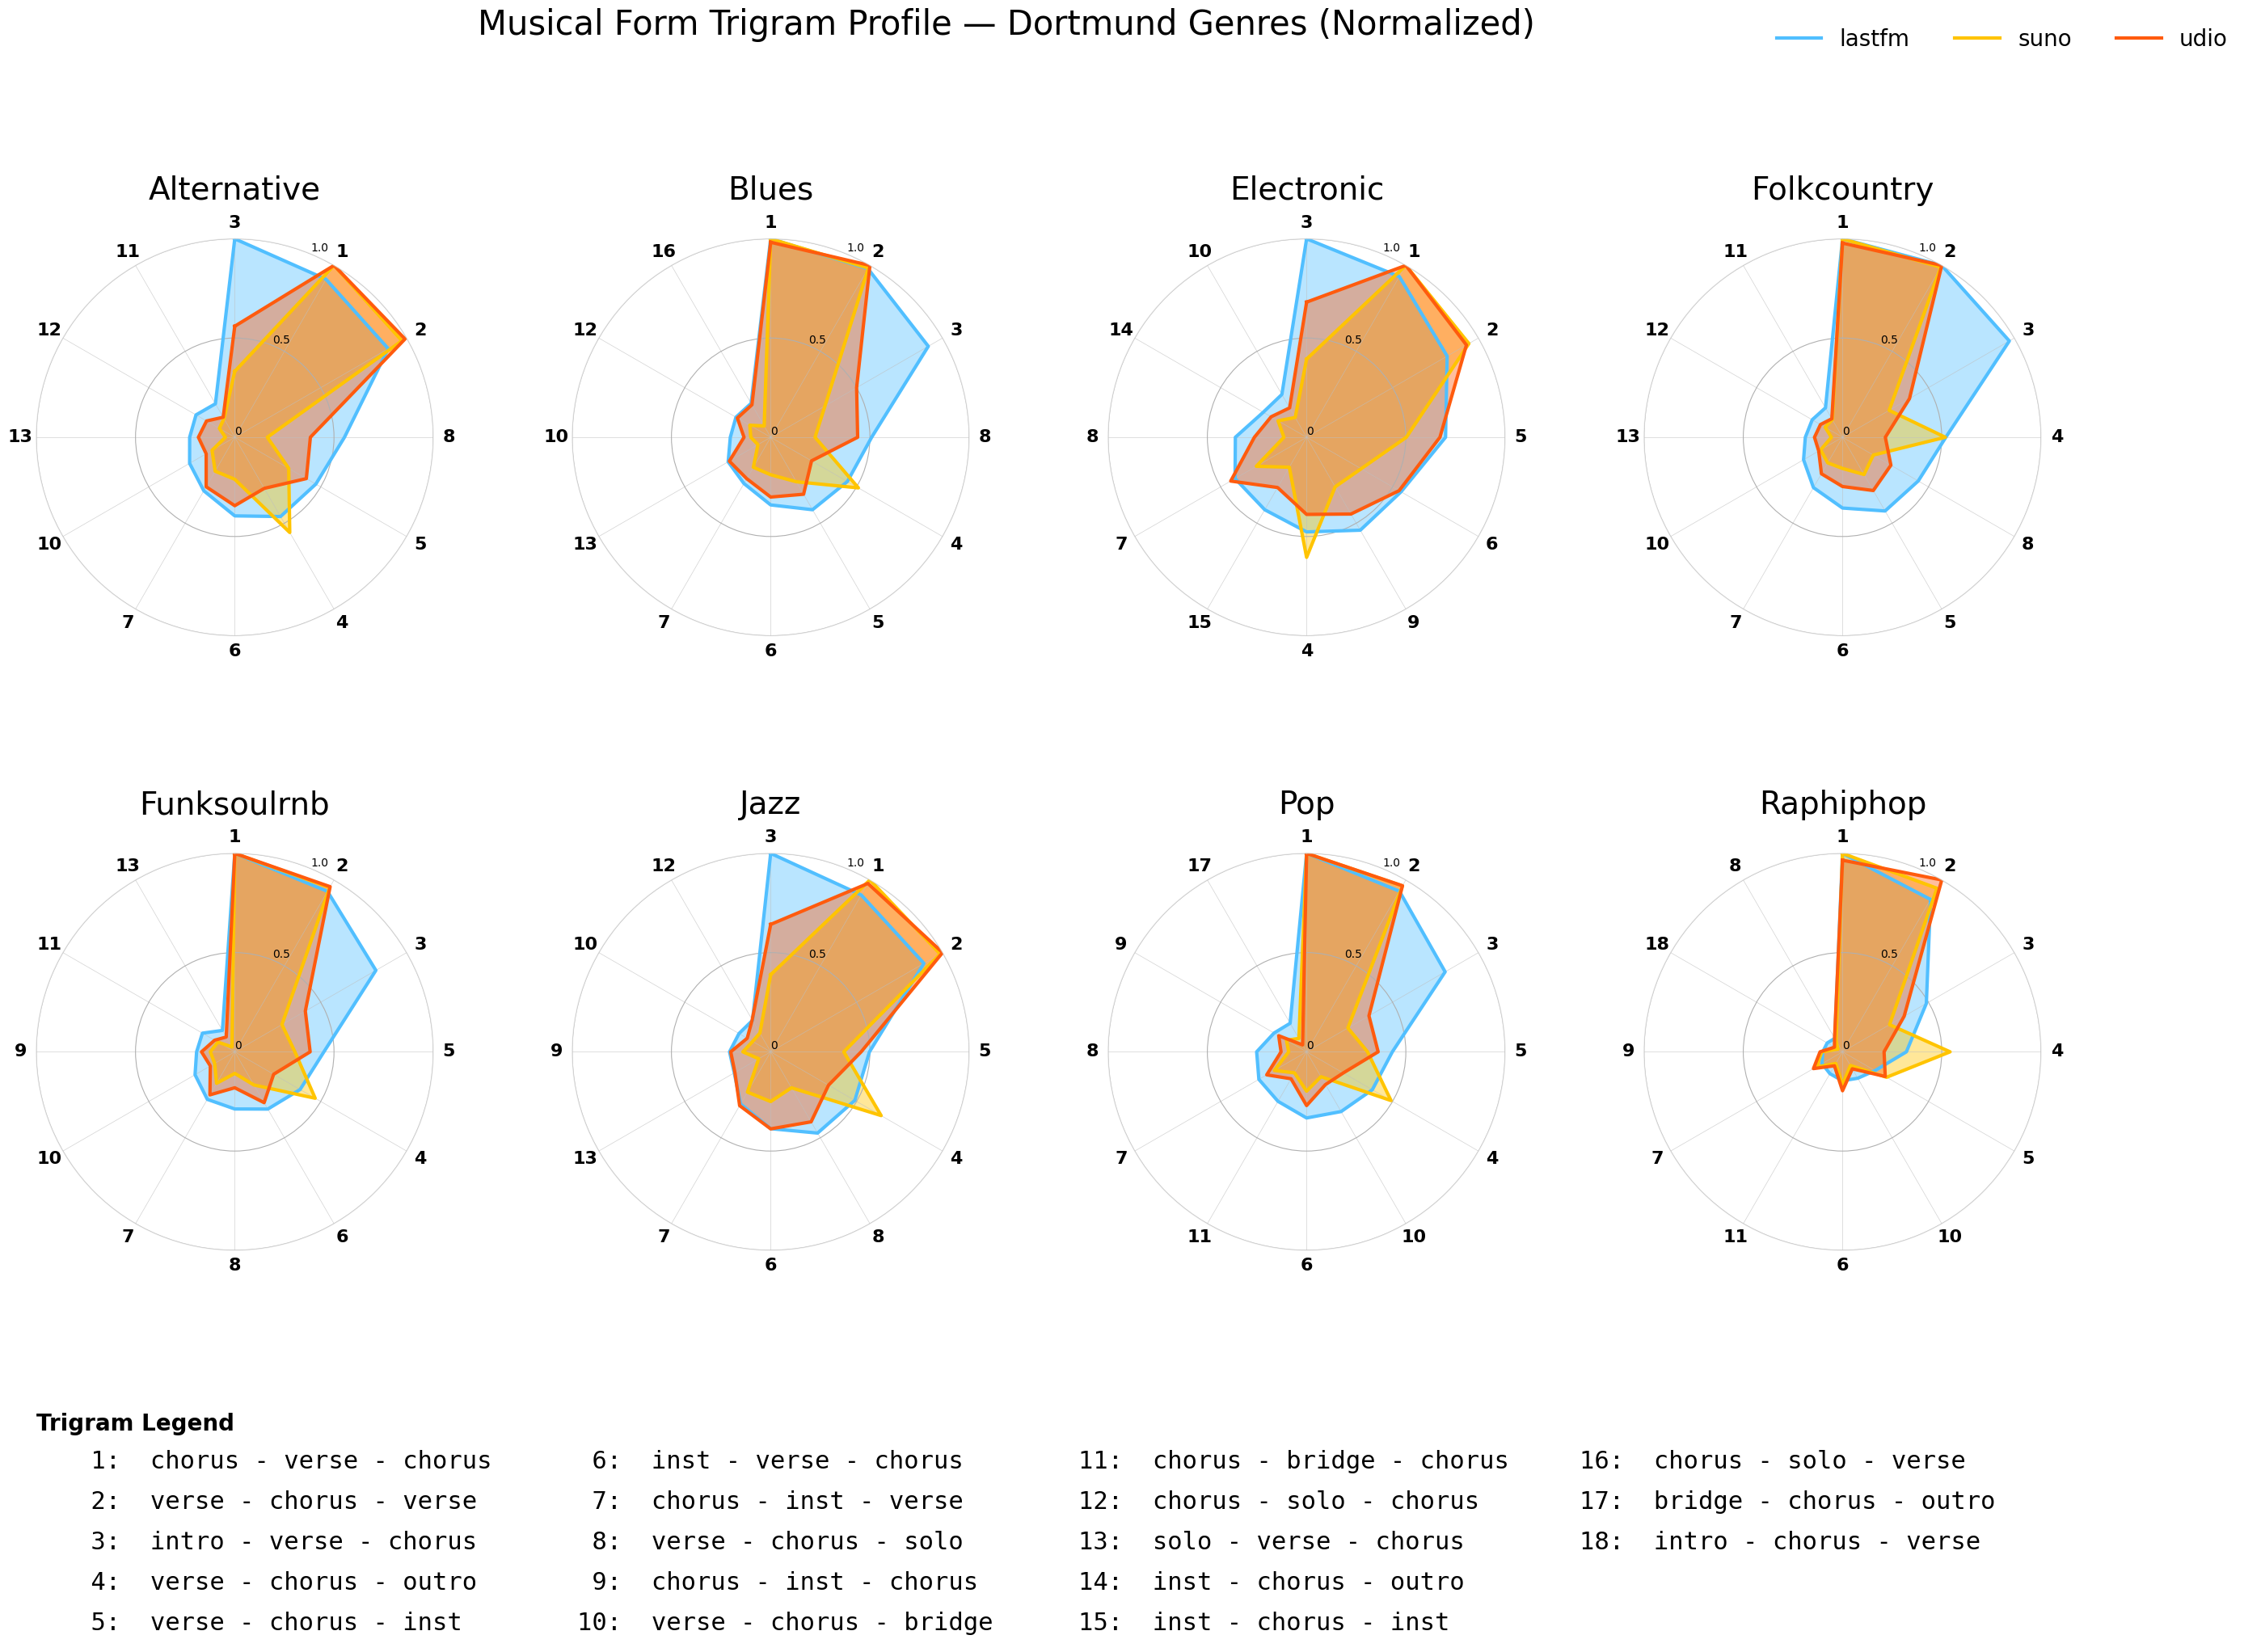

In [ ]:
# ── Dortmund genres: proportional style analysis ──
# Global trigram numbering: one consistent number per unique trigram across all genres
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec

proportional_entries = []
for collection in COLLECTIONS:
    for song_id, sections, dortmund, human_styles in collection_data[collection]:
        filtered = [s for s in sections if s not in ('start', 'end')]
        collapsed = collapse_repeats(filtered)
        trigrams = [tuple(collapsed[i:i+3]) for i in range(len(collapsed)-2)]
        if not trigrams or not dortmund:
            continue
        for genre, weight in dortmund.items():
            proportional_entries.append({
                'collection': collection, 'genre': genre,
                'trigrams': trigrams, 'weight': weight
            })

genre_counts = Counter(e['genre'] for e in proportional_entries if e['genre'])
top_genres = [g for g, _ in genre_counts.most_common(8)]

trigram_counts_by_genre = defaultdict(lambda: defaultdict(Counter))
for entry in proportional_entries:
    genre = entry['genre']
    if genre not in top_genres:
        continue
    collection = entry['collection']
    for trigram in entry['trigrams']:
        trigram_counts_by_genre[genre][collection][trigram] += entry['weight']

all_rows = []
for genre in top_genres:
    all_trigrams = Counter()
    for collection in COLLECTIONS:
        all_trigrams += trigram_counts_by_genre[genre][collection]
    top20_trigrams = [t for t, _ in all_trigrams.most_common(20)]
    for trigram in top20_trigrams:
        trigram_str = ' - '.join(trigram)
        for collection in COLLECTIONS:
            count = trigram_counts_by_genre[genre][collection][trigram]
            all_rows.append({'genre': genre, 'trigram': trigram_str,
                             'collection': collection, 'count': count})

df_long2 = pd.DataFrame(all_rows)
df_long2['normalized_count'] = 0.0
for genre in df_long2['genre'].unique():
    for collection in COLLECTIONS:
        mask = (df_long2['genre'] == genre) & (df_long2['collection'] == collection)
        max_count = df_long2.loc[mask, 'count'].max()
        if max_count > 0:
            df_long2.loc[mask, 'normalized_count'] = df_long2.loc[mask, 'count'] / max_count * 100
        else:
            df_long2.loc[mask, 'normalized_count'] = 0.0
df_long2['profile_ratio'] = df_long2['normalized_count'] / 100

# ── Radar chart with global trigram numbering ──
colors = [colors_coll[c] for c in COLLECTIONS]
N = 12
genres = df_long2['genre'].unique()
reference_collection = 'lastfm'

# 1. Get top trigrams per genre
trigram_order_per_genre = {}
for genre in genres:
    top_trigrams = (
        df_long2[(df_long2['genre'] == genre) & (df_long2['collection'] == reference_collection)]
        .groupby('trigram')['normalized_count'].sum()
        .sort_values(ascending=False).head(N).index.tolist()
    )
    trigram_order_per_genre[genre] = top_trigrams

# 2. Build global trigram → number mapping (ordered by overall frequency)
all_unique_trigrams2 = []
for genre in genres:
    for t in trigram_order_per_genre[genre]:
        if t not in all_unique_trigrams2:
            all_unique_trigrams2.append(t)
global_freq2 = df_long2.groupby('trigram')['count'].sum()
all_unique_trigrams2.sort(key=lambda t: global_freq2.get(t, 0), reverse=True)
global_trigram_num2 = {t: i+1 for i, t in enumerate(all_unique_trigrams2)}

# 3. Layout: spider grid + legend row at bottom
n_genres = len(genres)
n_cols = 4
n_rows = int(np.ceil(n_genres / n_cols))
fig = plt.figure(figsize=(n_cols * 8, n_rows * 8 + 7))
gs = gridspec.GridSpec(n_rows + 1, n_cols, figure=fig,
                       height_ratios=[1]*n_rows + [0.45],
                       hspace=0.45, wspace=0.35)

axes = []
for r in range(n_rows):
    for c in range(n_cols):
        ax = fig.add_subplot(gs[r, c], polar=True)
        axes.append(ax)

for ax_idx, genre in enumerate(genres):
    top_trigrams = trigram_order_per_genre[genre]
    num_vars = len(top_trigrams)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    axes[ax_idx].set_theta_offset(np.pi / 2)
    axes[ax_idx].set_theta_direction(-1)
    axes[ax_idx].spines['polar'].set_color("#D5D5D5")
    axes[ax_idx].spines['polar'].set_linewidth(1.0)
    axes[ax_idx].spines['polar'].set_alpha(0.5)

    for col, color in zip(COLLECTIONS, colors):
        subset = df_long2[(df_long2['genre'] == genre) & (df_long2['collection'] == col)]
        subset = subset.set_index('trigram')
        data = [subset.loc[t, 'profile_ratio'] if t in subset.index else 0 for t in top_trigrams]
        data += data[:1]
        axes[ax_idx].plot(angles, data, color=color, label=col, linewidth=3)
        axes[ax_idx].fill(angles, data, color=color, alpha=0.2)

    axes[ax_idx].set_xticks(angles[:-1])
    axes[ax_idx].set_xticklabels([str(global_trigram_num2[t]) for t in top_trigrams],
                                  fontsize=16, fontweight='bold')
    axes[ax_idx].set_yticks([0, 0.5, 1.0])
    axes[ax_idx].set_yticklabels(['0', '0.5', '1.0'])
    axes[ax_idx].set_ylim(0, 1)
    axes[ax_idx].xaxis.grid(True, color="#BFBFBF", linewidth=0.5, alpha=0.7)
    axes[ax_idx].set_title(f"{genre.title()}", fontsize=28, pad=35)

for ax in axes[len(genres):]:
    ax.set_visible(False)

# Collection legend
line_handles = [mlines.Line2D([], [], color=color, linewidth=3, label=col)
                for col, color in zip(COLLECTIONS, colors)]
fig.legend(handles=line_handles, labels=COLLECTIONS,
           loc='upper right', bbox_to_anchor=(0.98, 0.99), fontsize=20, frameon=False, ncol=3)

# Legend table at bottom
ax_legend = fig.add_subplot(gs[n_rows, :])
ax_legend.axis('off')

sorted_items = sorted(global_trigram_num2.items(), key=lambda x: x[1])
n_items = len(sorted_items)
n_legend_cols = 4
rows_per_col = int(np.ceil(n_items / n_legend_cols))

for idx, (trigram, num) in enumerate(sorted_items):
    col_idx = idx // rows_per_col
    row_idx = idx % rows_per_col
    x = col_idx / n_legend_cols + 0.02
    y = 1.0 - (row_idx + 0.5) / rows_per_col
    ax_legend.text(x, y, f"{num:>2d}:  {trigram}", fontsize=22, family='monospace',
                   va='center', ha='left', transform=ax_legend.transAxes)

ax_legend.set_title("Trigram Legend", fontsize=20, fontweight='bold', loc='left', pad=10)
plt.suptitle("Musical Form Trigram Profile — Dortmund Genres (Normalized)", fontsize=30, y=0.99)
plt.savefig('../Figures/musical_form_trigram_genres_spider.png', dpi=300, bbox_inches='tight')
plt.show()